/tmp/ipykernel_75223/3031542058.py:6: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed in 3.10.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use('TkAgg')  # Use Agg backend for non-interactive plotting


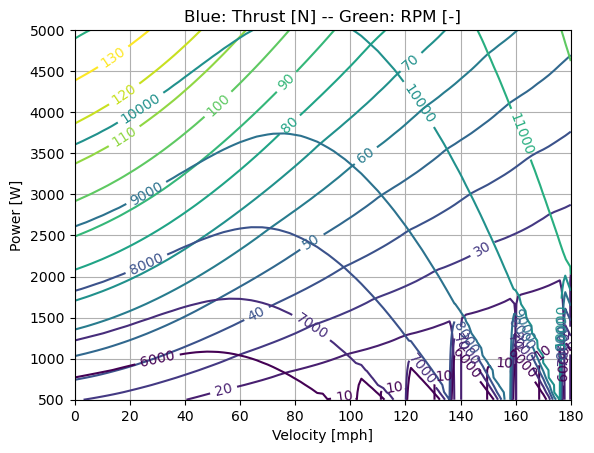

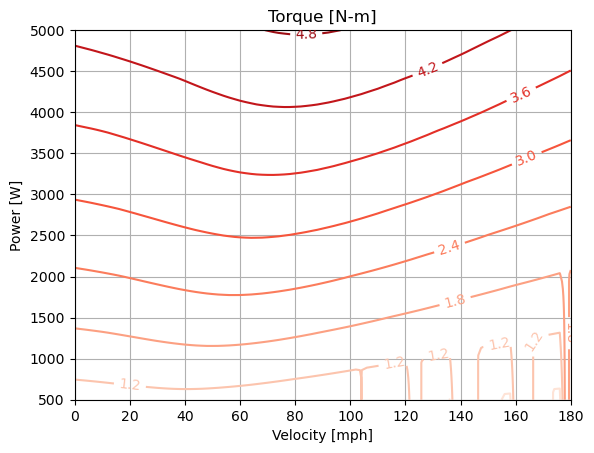

In [49]:
import numpy as np
import scipy.optimize as spo


import matplotlib
matplotlib.use('TkAgg')  # Use Agg backend for non-interactive plotting
%matplotlib inline
import matplotlib.pyplot as plt

f = open('/home/bkturnour/DBF2025/APC/PER3_16x16.dat','r')
data = f.read()
f.close()
# print(data)

rpm_blocks = data.split('PROP RPM')
# print(rpm_blocks[2])

headers = ['V','J','Pe','Ct','Cp','PWR_S','Torque_S','Thrust_S','PWR_M','Torque_M','Thrust_M','THR/PWR','Mach','Reyn','FOM']
units = ['(mph)','(Adv_Ratio)','-','-','-','(Hp)','(In-Lbf)','(Lbf)','(W)','(N-m)','(N)','(g/W)','-','-','-']

read_data = {}

for block in rpm_blocks[1:]:
    lines = block.split('\n')
    rpm_value = None
    for ln in lines:
        if '=' in ln:
            ents = ln.split()
            rpm_value = float(ents[1])
            temp_row = []
            for i in range(0,len(headers)):
                temp_row.append([])
            read_data[rpm_value] = dict(zip(headers,temp_row))
        else:
            ents = ln.split()
            if len(ents)>0:
                if ents[0] == 'V':
                    # headers in line
                    pass
                elif ents[0] == '(mph)':
                    #units line
                    pass
                else:
                    # print(ents)
                    if len(ents) == len(headers):
                        for i, ent in enumerate(ents):
                            read_data[rpm_value][headers[i]].append( float(ent) )

V_array = np.linspace(0,218,219)

tbl = {}

for v in V_array:
    valid_rpms = []
    for rpm, dta in read_data.items():
        if v >= dta['V'][0] and v <= dta['V'][-1]:
            valid_rpms.append(rpm)

    if len(valid_rpms) > 1:
        tbl[v] = {}
        tbl[v]['Thrust_M'] = []
        tbl[v]['Torque_M'] = []
        tbl[v]['RPM']      = valid_rpms

        for rpm in valid_rpms:
            Thrust_M = np.interp(v, read_data[rpm]['V'], read_data[rpm]['Thrust_M'])
            Torque_M = np.interp(v, read_data[rpm]['V'], read_data[rpm]['Torque_M'])
            tbl[v]['Thrust_M'].append(Thrust_M)
            tbl[v]['Torque_M'].append(Torque_M)

omg = np.linspace(0,1500,102)
trq = np.linspace(0,6,101)
oo,tt = np.meshgrid(omg[1:],trq)
pp = oo*tt

# for v in 10*np.linspace(0,18,10):
#     fig, ax = plt.subplots()
#     CS = ax.contour(oo* 60/ (2*np.pi),tt,20/17.5*pp, levels=[100,250,500,750,1000,1500,2000,3000,4000,5000,6000,7000,8000,9000])
#     ax.clabel(CS, inline=True, fontsize=10)
    
#     plt.plot(np.array(tbl[v]['RPM']), tbl[v]['Torque_M'],'r-')
#     plt.plot(7000,2.4,'m^')
#     plt.plot(8000,2.99,'c^')
#     plt.plot(5822,1.318,'g^')
    
#     plt.ylabel('Torque [N-m]')
#     plt.xlabel('RPM [-]')
#     plt.xlim([0,14000])
#     plt.ylim([0,6])
#     plt.grid(1)
#     plt.title('V=%.2f'%(v))


v_mg = np.linspace(0,180,91)
p_mg = np.linspace(500,5000,51)
vv,pp = np.meshgrid(v_mg, p_mg)

tt = 0.0*vv

def residual(x,p,rpm,trq):
    trq_val = np.interp(x,rpm,trq)
    p_val = trq_val * (x*2*np.pi/60)
    return 100*(p_val - p)
    

for i in range(0,len(vv)):
    for j in range(0,len(vv[0])):
        v = vv[i,j]
        p = pp[i,j]

        res = spo.root(residual, 8000 ,args=(p,tbl[v]['RPM'],tbl[v]['Torque_M']))
        if res['message'] == 'The solution converged.' or res['fun'] < 1e-10:
            rpm_balanced = res['x'][0]
        else:
            raise RuntimeError('Failed to find valid solution')
            
        tt[i,j] = np.interp(rpm_balanced, tbl[v]['RPM'], tbl[v]['Thrust_M'] )










# plt.figure()
fig, ax = plt.subplots()
# CS = ax.contour(oo* 60/ (2*np.pi),tt,pp, levels=[100,250,500,750,1000,1500,2000,3000,4000,5000,6000,7000,8000,9000])
CS = ax.contour(vv,pp,tt,levels=10*np.linspace(1,13,13))
ax.clabel(CS, inline=True, fontsize=10)
# plt.contourf(vv,pp,tt,levels=11, cmap='Greens') 
plt.xlabel('Velocity [mph]')
plt.ylabel('Power [W]')
# plt.colorbar(label='Thrust [N]')
plt.title('Thrust [N]')
# plt.ylim(ymin=1000)
plt.grid(1)


v_mg = np.linspace(0,180,91)
p_mg = np.linspace(500,5000,51)
vv,pp = np.meshgrid(v_mg, p_mg)

rr = 0.0*vv

def residual(x,p,rpm,trq):
    trq_val = np.interp(x,rpm,trq)
    p_val = trq_val * (x*2*np.pi/60)
    return 100*(p_val - p)
    

for i in range(0,len(vv)):
    for j in range(0,len(vv[0])):
        v = vv[i,j]
        p = pp[i,j]

        res = spo.root(residual, 8000 ,args=(p,tbl[v]['RPM'],tbl[v]['Torque_M']))
        if res['message'] == 'The solution converged.' or res['fun'] < 1e-10:
            rr[i,j] = res['x'][0]
        else:
            raise RuntimeError('Failed to find valid solution')
            
        # tt[i,j] = np.interp(rpm_balanced, tbl[v]['RPM'], tbl[v]['Thrust_M'] )

# plt.figure()
# fig, ax = plt.subplots()
# CS = ax.contour(oo* 60/ (2*np.pi),tt,pp, levels=[100,250,500,750,1000,1500,2000,3000,4000,5000,6000,7000,8000,9000])
CS = ax.contour(vv,pp,rr, levels=1000*np.linspace(6,14,9))
ax.clabel(CS, inline=True, fontsize=10)
# plt.contourf(vv,pp,tt,levels=11, cmap='Greens')
plt.xlabel('Velocity [mph]')
plt.ylabel('Power [W]')
# plt.colorbar(label='Thrust [N]')
plt.title('Blue: Thrust [N] -- Green: RPM [-]')
# plt.ylim(ymin=1000)
plt.grid(1)
#plt.ylim([1500,4000])


v_mg = np.linspace(0,180,91)
p_mg = np.linspace(500,5000,51)
vv,pp = np.meshgrid(v_mg, p_mg)

qq = 0.0*vv

def residual(x,p,rpm,trq):
    trq_val = np.interp(x,rpm,trq)
    p_val = trq_val * (x*2*np.pi/60)
    return 100*(p_val - p)
    

for i in range(0,len(vv)):
    for j in range(0,len(vv[0])):
        v = vv[i,j]
        p = pp[i,j]

        res = spo.root(residual, 8000 ,args=(p,tbl[v]['RPM'],tbl[v]['Torque_M']))
        if res['message'] == 'The solution converged.' or res['fun'] < 1e-10:
            rpm_balanced = res['x'][0]
        else:
            raise RuntimeError('Failed to find valid solution')
            
        qq[i,j] = np.interp(rpm_balanced, tbl[v]['RPM'], tbl[v]['Torque_M'] )

# plt.figure()
fig, ax = plt.subplots()
# CS = ax.contour(oo* 60/ (2*np.pi),tt,pp, levels=[100,250,500,750,1000,1500,2000,3000,4000,5000,6000,7000,8000,9000])
CS = ax.contour(vv,pp,qq,cmap='Reds')#,levels=10*np.linspace(1,13,13),cmap='plasma')
ax.clabel(CS, inline=True, fontsize=10)
# plt.contourf(vv,pp,tt,levels=11, cmap='Greens')
plt.xlabel('Velocity [mph]')
plt.ylabel('Power [W]')
# plt.colorbar(label='Thrust [N]')
plt.title('Torque [N-m]')
# plt.ylim(ymin=1000)
plt.grid(1)
plt.show()

In [50]:
plt.figure()
for v in 10*np.linspace(0,18,10):
    plt.plot(tbl[v]['RPM'], tbl[v]['Thrust_M'])
    # plt.plot(tbl[10]['RPM'], tbl[10]['Torque_M'])
plt.xlabel('RPM [-]')
plt.ylabel('Thrust [N]')
# plt.xlim([0,14000])
# plt.ylim([0,6])
plt.grid(1)

In [51]:
import numpy as np
import scipy.optimize as spo


def generate_thrust_data(p_mg=2600):
    # p_mg = 2600
    
    # f = open('prop.dat','r')
    f = open('PER3_16x16.dat','r')
    data = f.read()
    f.close()
    
    rpm_blocks = data.split('PROP RPM')
    
    headers = ['V','J','Pe','Ct','Cp','PWR_S','Torque_S','Thrust_S','PWR_M','Torque_M','Thrust_M','THR/PWR','Mach','Reyn','FOM']
    units = ['(mph)','(Adv_Ratio)','-','-','-','(Hp)','(In-Lbf)','(Lbf)','(W)','(N-m)','(N)','(g/W)','-','-','-']
    
    read_data = {}
    
    for block in rpm_blocks[1:]:
        lines = block.split('\n')
        rpm_value = None
        for ln in lines:
            if '=' in ln:
                ents = ln.split()
                rpm_value = float(ents[1])
                temp_row = []
                for i in range(0,len(headers)):
                    temp_row.append([])
                read_data[rpm_value] = dict(zip(headers,temp_row))
            else:
                ents = ln.split()
                if len(ents)>0:
                    if ents[0] == 'V':
                        # headers in line
                        pass
                    elif ents[0] == '(mph)':
                        #units line
                        pass
                    else:
                        # print(ents)
                        if len(ents) == len(headers):
                            for i, ent in enumerate(ents):
                                read_data[rpm_value][headers[i]].append( float(ent) )
    
    # V_array = np.linspace(0,218,219)
    V_array = np.linspace(0,210,211)
    
    tbl = {}
    
    for v in V_array:
        valid_rpms = []
        for rpm, dta in read_data.items():
            if v >= dta['V'][0] and v <= dta['V'][-1]:
                valid_rpms.append(rpm)
    
        if len(valid_rpms) > 1:
            tbl[v] = {}
            tbl[v]['Thrust_M'] = []
            tbl[v]['Torque_M'] = []
            tbl[v]['RPM']      = valid_rpms
    
            for rpm in valid_rpms:
                Thrust_M = np.interp(v, read_data[rpm]['V'], read_data[rpm]['Thrust_M'])
                Torque_M = np.interp(v, read_data[rpm]['V'], read_data[rpm]['Torque_M'])
                tbl[v]['Thrust_M'].append(Thrust_M)
                tbl[v]['Torque_M'].append(Torque_M)
    
    # v_mg = np.linspace(0,180,91)
    v_mg = np.linspace(0,210,211)
    
    def residual(x,p,rpm,trq):
        trq_val = np.interp(x,rpm,trq)
        p_val = trq_val * (x*2*np.pi/60)
        return 100*(p_val - p)
    
    thrust = np.zeros(len(v_mg))
    rpms   = np.zeros(len(v_mg))
    for i,v in enumerate(v_mg):
        res = spo.root(residual, 8000 ,args=(p_mg,tbl[v]['RPM'],tbl[v]['Torque_M']))
        if res['message'] == 'The solution converged.' or res['fun'] < 1e-10:
            rpm_balanced = res['x'][0]
        else:
            raise RuntimeError('Failed to find valid solution')
        rpms[i] = rpm_balanced
        thrust[i] = np.interp(rpm_balanced, tbl[v]['RPM'], tbl[v]['Thrust_M'] )
    
    thrust *= 0.224809 # convert from newtons to pounds-force
    
    valid_indicies = []
    for i in range(0,len(thrust)):
        if i>0:
            if thrust[i]<thrust[valid_indicies[-1]]:
                valid_indicies.append(i)
            # else:
            #     print(i)
        else:
            valid_indicies.append(i)
    
    
    opt = np.array([v_mg[valid_indicies],thrust[valid_indicies], rpms[valid_indicies]]).T

    return opt





In [52]:
# clear all;
# close all;
# clc;
# set(0,'DefaultFigureWindowStyle','docked');

# pyenv(Version="/Users/codykarcher/software/miniconda3/bin/python");
# python_data = pyrunfile('analyze_propeller.py','opt');
# thrust_output = double(python_data);

# % Column 1:  Flight Velocity in Mile per Hour
# % Column 2:  Thrust in lbf
# % Column 3:  RPM

# data = thrust_output;

import scipy.optimize as spo
import numpy as np
import pint
units = pint.UnitRegistry()


varr = []
parr = np.linspace(500,3000,50)


def residuals(vguess,W_pl,S,data):
    vguess = vguess * units.mph
    S *= units.ft**2
    W_pl *= units.lbf
    V = vguess
    rho = 1.23 * units.kg/units.m**3
    Cdo = 0.013
    b = 6*units.ft
    e = 0.9
    
    W = 7.09*units.lbf + 3*0.067*(2.05*S.to('ft^2').magnitude)**(3/2)*units.lbf + W_pl
    
    rhs = 0.5 * rho * V**2 * ( Cdo + ((4*W**2)/(np.pi*e*b**2*rho**2*V**4*S)) ) * S
    lhs = np.interp(vguess.to('mph').magnitude, data[:,0],data[:,1])
    res = lhs - rhs.to('lbf').magnitude
    return res


for p in parr:
    
    # power_setting = 2600*units.W
    power_setting = p*units.W
    data = generate_thrust_data(power_setting.to('W').magnitude)

    res = spo.root(residuals, 1, args=(20,10,data))
    if res['message'] == 'The solution converged.':
        varr.append(res['x'][0])
    else:
        # if not, throw an error
        varr.append(None)
        # raise RuntimeError('Failed to find valid solution')
    
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(parr,varr)

varr=[]
for p in parr:
    
    # power_setting = 2600*units.W
    power_setting = p*units.W
    data = generate_thrust_data(power_setting.to('W').magnitude)

    res = spo.root(residuals, 100, args=(20,10,data))
    if res['message'] == 'The solution converged.':
        varr.append(res['x'][0])
    else:
        # if not, throw an error
        varr.append(None)
        # raise RuntimeError('Failed to find valid solution')
    
# import matplotlib.pyplot as plt
# %matplotlib inline
plt.plot(parr,varr)


# print(residuals(100,20,10, data))
# np.interp(100, data[:,0],data[:,2])

# s_array=np.linspace(0.01,50);
# w_array=np.linspace(0.01,20,30);
# [ss,ww]=meshgrid(s_array,w_array);
# vv=0*ss;

# grid_dims=size(ss);
# # options = optimoptions('fminunc','Display','off');
# for i=1:grid_dims(1)
#     for j=1:grid_dims(2)
#         W_pl=ww(i,j);
#         S=ss(i,j);
#         f = @(vguess)residuals(vguess,W_pl,S,data);
#         [res,fval,exitflag,output] = fminunc(f,100,options); #%res is velocity here only
#         rpm = interp1(data(:,1),data(:,3),res,"cubic");
#         if exitflag>0 && fval<=1e-8 %&& rpm<=9000
#             vv(i,j)=res;
#         else 
#             vv(i,j)=NaN;
#         end
#     end 
# end

# plt.contourf(ss,ww,vv)
# plt.colorbar


In [53]:
import scipy.optimize as spo
import numpy as np
import pint
units = pint.UnitRegistry()
import matplotlib.pyplot as plt
%matplotlib inline

rho = 1.23 * units.kg/units.m**3
Cdo = 0.013
b = 6*units.ft
e = 0.9

varr = np.linspace(1,250,100)
darr = []
W_pl = 0
S = 18
S *= units.ft**2
W_pl *= units.lbf
W = 7.09*units.lbf + 0.067*(2.05*S.to('ft^2').magnitude)**(3/2)*units.lbf + W_pl + 10*units.lbf
print(W)


carr = []
for vguess in varr:
    vguess = vguess * units.mph
    V = vguess
    cl = (W/(0.5 * rho * V**2 * S)).to('').magnitude
    carr.append(cl)

    D = 0.5 * rho * V**2 * ( Cdo + ((4*W**2)/(np.pi*e*b**2*rho**2*V**4*S)) ) * S
    darr.append(D.to('lbf').magnitude)
    # darr.append(D.to('N').magnitude*V.to('m/s').magnitude)


cf = 1.0*units.mph*units.lbf
# print(cf.to('W').magnitude)

plt.plot(varr,darr)
# # plt.plot(data[:,0],(data[:,1]*data[:,0]*cf.to('W').magnitude),'r')

parr = np.linspace(500,4000,5)
for p in parr:
    power_setting = p*units.W
    data = generate_thrust_data(power_setting.to('W').magnitude)
    plt.plot(data[:,0],data[:,1],'g-',alpha = p/4000)
    
power_setting = 1800*units.W
data = generate_thrust_data(power_setting.to('W').magnitude)
plt.plot(data[:,0],data[:,1],'r')
plt.plot(data[:,0],data[:,2]/1000,'k')

plt.plot(varr,10*np.array(carr),'m--')






# plt.plot([0,varr[-1]],[2600,2600],'r')
# plt.ylim([0,3000])
# plt.ylim([0,1.2*max(data[:,1])])
plt.ylim([0,20])
# plt.xlim([0,200])
plt.ylabel('Drag')
plt.xlabel('Velocity')

plt.grid(1)

32.1080778730502 force_pound


In [54]:
print(np.array([70, 156, 118])/256)
print(np.array([126, 194, 172])/256)
print(np.array([210, 234, 227])/256)
print(cf.to('W').magnitude)

[0.2734375 0.609375  0.4609375]
[0.4921875 0.7578125 0.671875 ]
[0.8203125  0.9140625  0.88671875]
1.9885329908860545
